
# Proyecto Final
A continuación, se utilizarán Python y las bibliotecas de análisis de datos pertinentes para responder las siguientes preguntas de investigación:<br/><br/>

**Análisis Exploratorio**

1.   ¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?
2.   ¿Qué grupos de municipios presentan patrones o comportamientos similares, mediante técnicas de clustering, respecto a la rapidez con la que se resuelven los casos, considerando la tasa de localización con vida frente a la tasa de no localización?
3.   ¿Existe alguna relación o patrón estacional entre los meses del año, como periodos vacacionales o trimestres específicos, y los incrementos repentinos en el número de registros?
<br/>

**Análisis Descriptivo**


1.   ¿Cuáles son los cinco estados con el mayor número acumulado de registros?
2.   ¿Qué proporción del total de casos corresponde a personas localizadas con vida, localizadas sin vida y personas que permanecen con estatus de no localizadas?

**Montar acceso a Google Drive.**

Se incorporará acceso a Google Drive, el cual será utilizado como repositorio central para el almacenamiento y la gestión de los datos del proyecto.

Esto permitirá contar con una ubicación centralizada para la información, facilitando el acceso, la colaboración y la administración de los conjuntos de datos que serán utilizados durante el análisis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importacion de bibliotecas y carga de Dataset**

Se importan las bibliotecas necesarias para el análisis y se carga un archivo consolidado que integra los cuatro conjuntos de datos obtenidos. En caso de ser necesario, la información será filtrada utilizando el campo status_id, dependiendo de los requerimientos específicos de cada análisis.

Este enfoque permite trabajar sobre una fuente de datos unificada, facilitando la exploración, transformación y análisis de la información de manera consistente a lo largo del proyecto.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/MIAAD/202602-AnaliticaDescriptivaPredictiva/Proyecto/Datos/all_desappiarences.csv')
df


,cvegeo,cve_estado,state,cve_mun,municipality,male,female,undefined,total,year,month,status_id
0,1001,1,aguascalientes,1,aguascalientes,19,21,0,40,2015,1,0
1,1001,1,aguascalientes,1,aguascalientes,7,14,0,21,2015,2,0
2,1001,1,aguascalientes,1,aguascalientes,12,23,0,35,2015,3,0
3,1001,1,aguascalientes,1,aguascalientes,17,28,0,45,2015,4,0
4,1001,1,aguascalientes,1,aguascalientes,11,24,0,35,2015,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
139300,32999,32,zacatecas,999,se desconoce,1,0,0,1,2024,1,3
139301,99998,99,unknown,999,se desconoce,0,1,0,1,2019,9,3
139302,99998,99,unknown,999,se desconoce,1,0,0,1,2019,10,3
139303,99998,99,unknown,999,se desconoce,0,1,0,1,2019,11,3


**Se valida si existen datos duplicados.**

Se realiza un conteo de los registros cargados en el DataFrame con el objetivo de validar el volumen de información importada. Posteriormente, se verificará la existencia de registros duplicados para garantizar la calidad de los datos antes de continuar con las etapas de limpieza, transformación y procesamiento.

Esta validación inicial permite asegurar la integridad del conjunto de datos y reducir posibles inconsistencias que pudieran afectar los resultados del análisis.

In [3]:
totalRecords = len(df)
print('Total de records: ',totalRecords)

#Total de records duplicados usando 'first'
duplicatedFirst = df.duplicated(keep='first').sum()
print("Duplicados (keep='first'): ", duplicatedFirst)


Total de records:  139305
Duplicados (keep='first'):  0


**Primera Pregunta**


Para responder a la primera pregunta de investigación, “***¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?***”, se comienza agrupando los datos por año y calculando los totales de las variables male, female, undefined y total.
<br/><br/>
Este análisis inicial permite obtener una visión general de la evolución de los registros a lo largo del tiempo e identificar posibles cambios en su comportamiento. Posteriormente, los resultados se representarán gráficamente con el fin de visualizar tendencias, incrementos o disminuciones significativas y evaluar la existencia de posibles quiebres estructurales a partir de 2017.
<br/><br/>
La combinación de análisis estadístico y visualización facilitará la detección de patrones temporales que puedan estar asociados con cambios normativos, administrativos o sociales ocurridos durante el periodo de estudio.

**Nota**: Se crea el DataFrame df_year

In [4]:
# Sumatoria por AÑO
df_year = (
    df.groupby('year')[['male', 'female', 'undefined', 'total']]
    .sum()
    .reset_index()
    .sort_values('year')
)

print('--- Sumatoria por Año ---')
df_year


--- Sumatoria por Año ---


,year,male,female,undefined,total
0,2015,15142,12804,14,27960
1,2016,17426,13198,22,30646
2,2017,21534,14216,48,35798
3,2018,22282,13930,118,36330
4,2019,31196,18470,404,50070
5,2020,30748,19714,46,50508
6,2021,32376,19550,14,51940
7,2022,31463,18668,54,50185
8,2023,39244,24827,60,64131
9,2024,44399,26594,38,71031


**Graficacion para responder Primera Pregunta.**

Una vez que la información ha sido filtrada y almacenada en el DataFrame df_year, se procede a la generación de las visualizaciones correspondientes.
<br/><br/>
Las gráficas permiten analizar de forma más clara la evolución de los registros a lo largo del tiempo, facilitando la identificación de tendencias, variaciones significativas y posibles cambios estructurales en la serie temporal. Asimismo, sirven como una herramienta complementaria al análisis estadístico para evaluar visualmente el comportamiento de las variables male, female, undefined y total a nivel anual.
<br/><br/>
A partir de estas representaciones gráficas, será posible realizar una evaluación preliminar sobre la existencia de cambios en la tendencia de los registros, particularmente en torno al año 2017, y determinar si se observan patrones que justifiquen análisis adicionales.

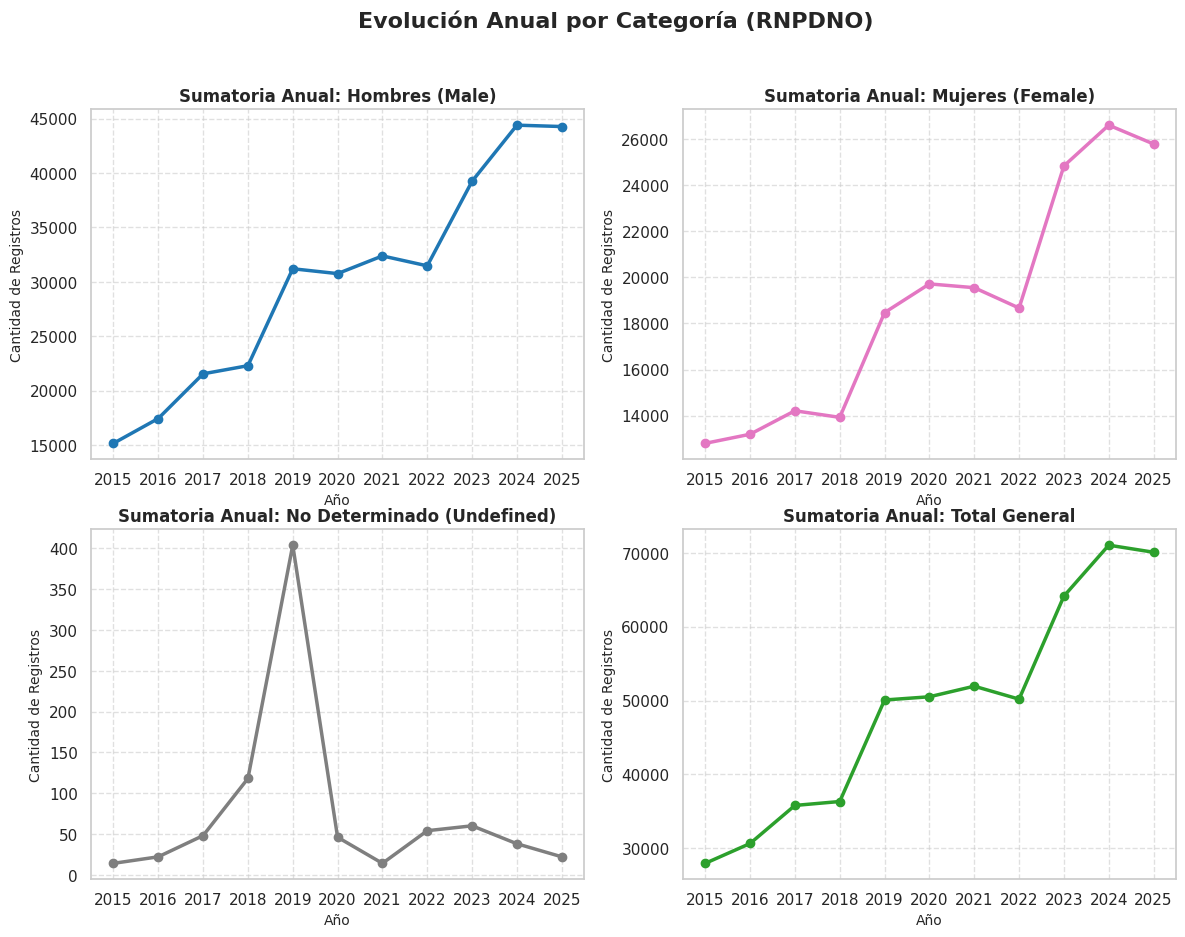

In [5]:
sns.set_theme(style='whitegrid')

# Creamos una figura de 2x2 para las 4 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Evolución Anual por Categoría (RNPDNO)', fontsize=16, fontweight='bold'
)

# Configuración de cada columna
config = [
    ('male', 'Hombres (Male)', '#1f77b4'),
    ('female', 'Mujeres (Female)', '#e377c2'),
    ('undefined', 'No Determinado (Undefined)', '#7f7f7f'),
    ('total', 'Total General', '#2ca02c'),
]

for ax, (col, titulo, color) in zip(axes.flatten(), config):
  ax.plot(
      df_year['year'],
      df_year[col],
      marker='o',
      linewidth=2.5,
      color=color,
      label=titulo,
  )

  ax.set_title(f'Sumatoria Anual: {titulo}', fontsize=12, fontweight='bold')
  ax.set_xlabel('Año', fontsize=10)
  ax.set_ylabel('Cantidad de Registros', fontsize=10)
  ax.set_xticks(df_year['year'].unique())
  ax.grid(True, linestyle='--', alpha=0.6)

**Respuesta a la pregunta "¿Se observa algún cambio estructural o quiebre de tendencia en la serie temporal a partir de 2017, coincidiendo con la promulgación de la Ley General en Materia de Desaparición Forzada de Personas?"**<br/>

Los resultados sugieren la existencia de un cambio en la tendencia de la serie temporal a partir de 2017. En la gráfica de registros totales se observa un incremento sostenido entre 2015 y 2017, seguido por una aceleración más marcada en los años posteriores, particularmente entre 2018 y 2019, cuando el número de registros aumenta de aproximadamente 36 mil a 50 mil casos.<br/>

Este comportamiento también se refleja en las categorías de hombres y mujeres, donde se aprecia un crecimiento más pronunciado después de 2017 en comparación con los años previos. Aunque la tendencia ya mostraba una trayectoria ascendente antes de 2017, los incrementos observados a partir de dicho año parecen indicar una posible modificación en la dinámica de registro y reporte de los casos.<br/>

La coincidencia temporal entre este cambio y la promulgación de la Ley General en Materia de Desaparición Forzada de Personas sugiere una posible relación. Sin embargo, a partir del análisis visual no es posible establecer una relación causal directa. <br/>

En conclusión, la evidencia gráfica indica un posible cambio de tendencia posterior a 2017, consistente con la hipótesis planteada, aunque se requiere un análisis estadístico formal para validar la magnitud y significancia de dicho cambio.



---



**Segunda Pregunta.**

Para responder a la pregunta ***¿Existe alguna relacion o patron estacional entre mes del año (ej. periodos vacacionales, o trimestres especificos) y el incremento repentino de registros?*** utilizaremos una grafica de boxplot para poder identificar variaciones y picos anomalos durante cada mes.


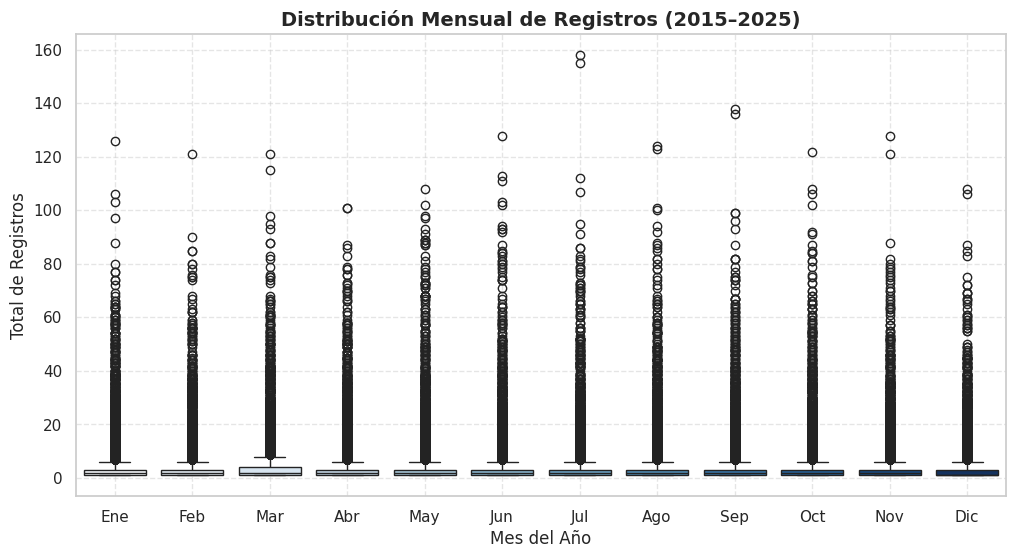

In [8]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='month', y='total', data=df, hue='month', palette='Blues', legend=False
)

plt.title(
    'Distribución Mensual de Registros (2015–2025)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Total de Registros', fontsize=12)
plt.xticks(
    range(0, 12),
    ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic',],
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Grafica Complementaria.**

Se agrega una grafica complementaria de Mapa de Calor Año vs Mes. Nos da la oportunidad de ver la intensidad de calor representando la cantidad de registros acumulados. Nos permite detectar instantaneamente posibles patrones estacionales recurrentes, distingue con claridad si un incremento ocurrio de manera aislada en un año.

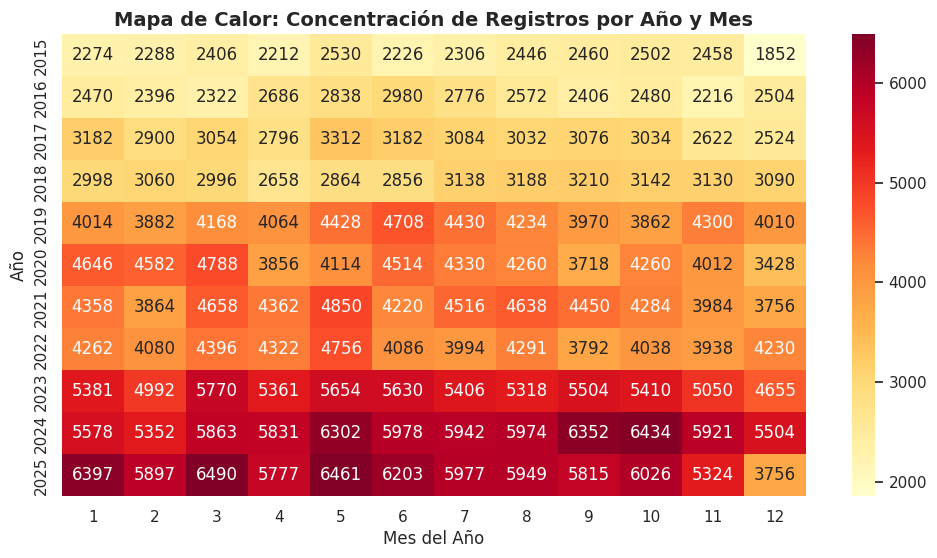

In [9]:
# Pivotar datos: Filas = Años, Columnas = Meses
df_pivot = df.pivot_table(
    index='year', columns='month', values='total', aggfunc='sum'
)

plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot, cmap='YlOrRd', annot=True, fmt='d', cbar=True)
plt.title(
    'Mapa de Calor: Concentración de Registros por Año y Mes',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Año', fontsize=12)
plt.show()

**Analisis y Respuesta.**

***1. Comportamiento central y estacionalidad general***
- *Estabilidad en el comportamiento típico:* Las cajas de todos los meses están comprimidas muy cerca de la parte inferior del eje $Y$
- *Ausencia de un patrón estacional estricto:* La mediana de los registros mensuales no muestra variaciones drásticas entre meses. No se aprecia una subida generalizada ni un pico sostenido en periodos vacacionales (julio, agosto, diciembre) a nivel típico municipal.

***2. Incrementos Repentinos y Eventos Anómalos (Outliers / Círculos)***
- *Aparición de picos atípicos:* Los círculos superiores representan eventos en los que ciertos municipios o periodos registraron incrementos repentinos de casos muy por encima del comportamiento normal.
- *Meses con mayor severidad en picos:*<br/>
  Julio y Junio: Presentan los puntos atípicos más altos de toda la serie histórica, alcanzando picos de cerca de 160 registros.
  Septiembre, Mayo y Noviembre: También registran picos elevados de entre 120 y 140 casos.
  Interpretacion: Aunque la estacionalidad no afecta al promedio general de todos los municipios, si existen picos o incrementos repentinos en ciertos meses especificos en ciertos municipios de alta incidencia.

***Conclusion: ***

De acuerdo con la distribucion mensual de registros (2015-2025) tenemos que:


1.   No existe un patron estacional generalizado. La mediana de registros a nivel municipal se mantiene estable durante todos los meses, descartando que los periodos vacacionales afecten de forma uniforme a toda la muestra.
2.   Presencia de picos Atipicos focalizados. Se observan incrementos repentinos anomalos (outliers) representados por eventos extremos que superan los 100 y 150 registros en un solo mes, los picos de mayor magnitud se presentan en Julio y Septiembre
3.   Interpretacion practica: Los incrementos repentinos no responden a un fenómeno calendario global.


  
